# Industry Ready Loan Approval ML Project
End-to-end ML workflow including preprocessing, models, explainability, and basic production components.

## 1. Install Required Libraries

In [8]:
# !pip install xgboost lightgbm shap

## 2. Import Libraries

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import xgboost as xgb
import lightgbm as lgb
import shap

import joblib


## 3. Load Dataset

In [10]:
df = pd.read_csv("loan_approved.csv")
print(df.shape)
df.head()

(614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 4. Data Cleaning

In [11]:
df.columns = df.columns.str.strip()

if "Loan_ID" in df.columns:
    df.drop(columns=["Loan_ID"], inplace=True)

df.rename(columns={
    "ApplicantIncome":"Applicant_Income",
    "CoapplicantIncome":"Coapplicant_Income",
    "LoanAmount":"Loan_Amount",
    'Loan_Status (Approved)':'Loan_Status'
}, inplace=True)


## 5. Feature Engineering

In [12]:
df["Total_Income"] = df["Applicant_Income"] + df["Coapplicant_Income"]
df["EMI"] = df["Loan_Amount"] / df["Loan_Amount_Term"]


## 6. Encode Target

In [13]:
df["Loan_Status"] = df["Loan_Status"].map({"Y":1,"N":0})

## 7. Train Test Split

In [14]:
X = df.drop("Loan_Status",axis=1)
y = df["Loan_Status"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)


## 8. Preprocessing Pipeline

In [15]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(include=["int64","float64"]).columns

num_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num",num_pipeline,numerical_cols),
    ("cat",cat_pipeline,categorical_cols)
])


## 9. Baseline RandomForest Model

In [16]:
rf_model = Pipeline([
    ("preprocessor",preprocessor),
    ("model",RandomForestClassifier())
])

rf_model.fit(X_train,y_train)

preds = rf_model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,preds))
print(classification_report(y_test,preds))


Accuracy: 0.8211382113821138
              precision    recall  f1-score   support

           0       0.75      0.63      0.69        38
           1       0.85      0.91      0.88        85

    accuracy                           0.82       123
   macro avg       0.80      0.77      0.78       123
weighted avg       0.82      0.82      0.82       123



## 10. XGBoost Model

In [17]:
xgb_model = Pipeline([
    ("preprocessor",preprocessor),
    ("model",xgb.XGBClassifier(n_estimators=200,max_depth=5,learning_rate=0.05))
])

xgb_model.fit(X_train,y_train)

xgb_preds = xgb_model.predict(X_test)

print("XGBoost Accuracy:",accuracy_score(y_test,xgb_preds))


XGBoost Accuracy: 0.8292682926829268


## 11. LightGBM Model

In [18]:
lgb_model = Pipeline([
    ("preprocessor",preprocessor),
    ("model",lgb.LGBMClassifier(n_estimators=200,learning_rate=0.05))
])

lgb_model.fit(X_train,y_train)

lgb_preds = lgb_model.predict(X_test)

print("LightGBM Accuracy:",accuracy_score(y_test,lgb_preds))


[LightGBM] [Info] Number of positive: 337, number of negative: 154
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000278 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 661
[LightGBM] [Info] Number of data points in the train set: 491, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.686354 -> initscore=0.783130
[LightGBM] [Info] Start training from score 0.783130
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

c:\Users\LENOVO\Desktop\Compelet Industry loan Approval Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 12. Feature Importance

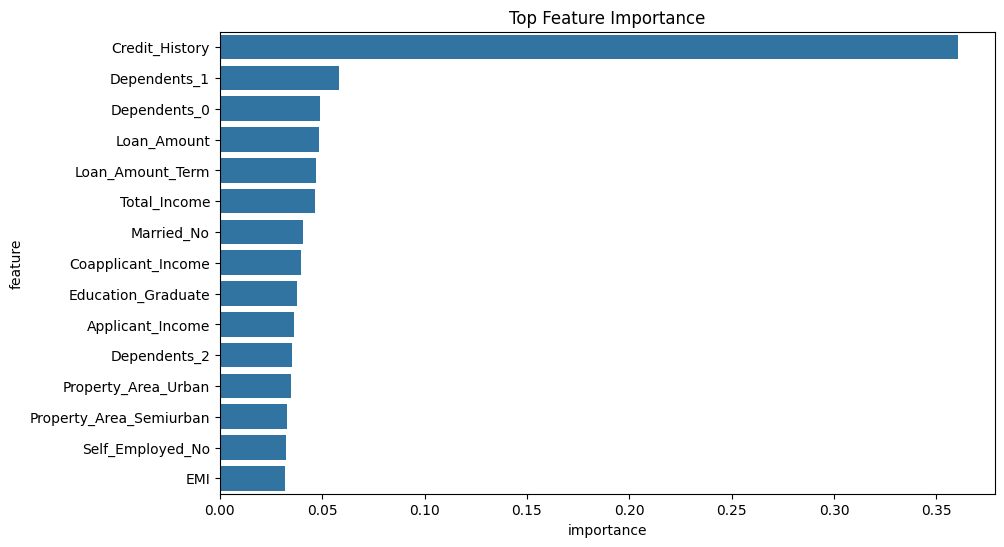

In [19]:
cat_features = xgb_model.named_steps["preprocessor"]     .named_transformers_["cat"]     .named_steps["encoder"]     .get_feature_names_out(categorical_cols)

all_features = list(numerical_cols) + list(cat_features)

importances = xgb_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "feature":all_features,
    "importance":importances
}).sort_values(by="importance",ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="importance",y="feature",data=feature_importance.head(15))
plt.title("Top Feature Importance")
plt.show()


## 13. SHAP Explainability

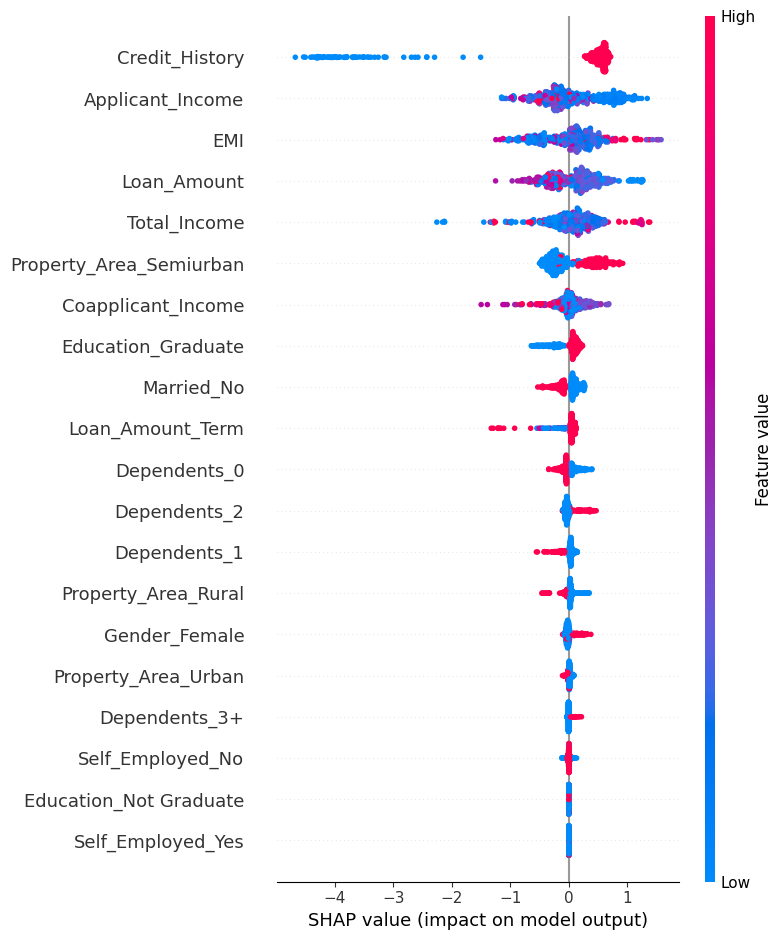

In [20]:
X_processed = xgb_model.named_steps["preprocessor"].transform(X_train)

explainer = shap.TreeExplainer(xgb_model.named_steps["model"])

shap_values = explainer.shap_values(X_processed)

shap.summary_plot(shap_values, X_processed, feature_names=all_features)


## 14. Save Model

In [21]:
joblib.dump(xgb_model,"loan_model.pkl")

['loan_model.pkl']

In [8]:
import joblib
import pandas as pd

## 15. Prediction Function

In [9]:
model = joblib.load('model/loan_model.pkl')

def predict_loan(data):
    df = pd.DataFrame([data])
    pred = model.predict(df)[0]
    return "Loan Approved" if pred==1 else "Loan Rejected"


## 16. Example Prediction

In [10]:
sample = {
"Gender":"Male",
"Married":"Yes",
"Dependents":"0",
"Education":"Graduate",
"Self_Employed":"No",
"Applicant_Income":5000,
"Coapplicant_Income":2000,
"Loan_Amount":150,
"Loan_Amount_Term":360,
"Credit_History":1,
"Property_Area":"Urban",
"Total_Income":7000,
"EMI":0.41
}

predict_loan(sample)


'Loan Approved'